# a better version of feedback simulator

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [48]:
# Settings
data_dir = '/DATAPOOL/VPMB/BIDS-VPMB-SPE'
#data_dir = '/home/alexandresayal/mnt/DATAPOOL/VPMB/BIDS-VPMB-SPE'
tc_dir = os.path.join(data_dir,'derivatives','timecourses')
output_dir = os.path.join(data_dir,'derivatives','feedbackSimulator')

subject_list = [x for x in os.listdir(data_dir) if 'sub-' in x]
subject_list.sort()

tr_list = [0.5, 0.75, 1, 2.5]
n_volumes_list = [780, 520, 390, 156]
run_list = ['UA']
hrf_delay = 0 # in seconds
roi_list = ['left_mt','right_mt','left_v1','right_v1']

In [49]:
# Load each timecourse from npy files in tc_dir
# split them into the four ROIs (left_mt, right_mt, left_v1, right_v1)
# and save them in a dataframe with the following columns: subject, tr, run, left_mt, right_mt, left_v1, right_v1, bilateral_mt, bilateral_v1

df = pd.DataFrame(columns=['subject','tr','run','left_mt','right_mt','left_v1','right_v1','bilateral_mt','bilateral_v1'])

for ss,subject in enumerate(subject_list):
    for tt,tr in enumerate(tr_list):
        for rr,run in enumerate(run_list):
            tc_file = os.path.join(tc_dir,f"{subject}_{tr}_{run}_hp_std-zscoresample_ss.npy")
            tc = np.load(tc_file)

            # estimate percent signal change for each roi (mean = 100, variation relative to mean, as in TBV)
            # tc_0 = tc[:,0] / abs(np.mean(tc[:,0])) * 100
            # tc_1 = tc[:,1] / abs(np.mean(tc[:,1])) * 100
            # tc_2 = tc[:,2] / abs(np.mean(tc[:,2])) * 100
            # tc_3 = tc[:,3] / abs(np.mean(tc[:,3])) * 100

            # estimate mean of first and last two rois (creating bilateral_mt and bilateral_v1)
            tc_mean1 = np.mean(tc[:,0:2], axis=1)
            tc_mean2 = np.mean(tc[:,2:4], axis=1)

            # add row to dataframe
            df.loc[len(df)] = [subject, tr, run, tc[:,0], tc[:,1], tc[:,2], tc[:,3], tc_mean1, tc_mean2]    

roi_list = ['left_mt','right_mt','left_v1','right_v1','bilateral_mt','bilateral_v1']

In [6]:
# tests
tc_file = os.path.join(tc_dir,'sub-01_0.5_AA_hp_ss.npy')
tc = np.load(tc_file)

# estimate percent signal change for each roi (mean = 100, variation relative to mean, as in TBV)
tc_0 = tc[:,0] / np.mean(tc[:,0]) * 100
tc_1 = tc[:,1] / np.mean(tc[:,1]) * 100

# mean of tc_0 and tc_1
tc_mean = np.mean([tc_0,tc_1],axis=0)

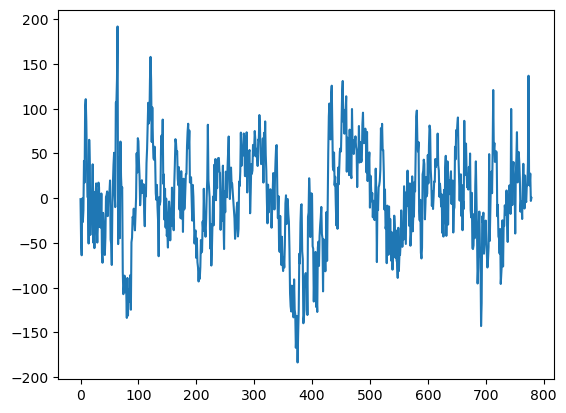

In [7]:
plt.plot(tc[:,0])

In [8]:
df

,subject,tr,run,left_mt,right_mt,left_v1,right_v1,bilateral_mt,bilateral_v1
0,sub-01,0.50,UA,"[-0.33926728, -1.1907738, -0.7945119, 1.091168...","[-0.43873116, -1.0981828, -1.5963974, 0.187625...","[0.10486642, 0.23840159, -0.21122286, -1.15020...","[-0.023075555, 0.06286354, -0.2364837, -0.6602...","[-0.38899922, -1.1444783, -1.1954546, 0.639397...","[0.040895432, 0.15063256, -0.22385328, -0.9052..."
1,sub-01,0.75,UA,"[-0.4330306, -0.4626376, 0.15811814, -0.247110...","[-0.47105327, -0.4001197, 0.8808069, 0.0386810...","[0.115366526, 0.63999164, -2.8293428, -2.01455...","[-0.13341802, 0.54886806, -2.4319155, -1.69323...","[-0.45204192, -0.43137866, 0.5194625, -0.10421...","[-0.009025749, 0.59442985, -2.630629, -1.85389..."
2,sub-01,1.00,UA,"[-0.037366275, -0.5924183, -1.4315312, 0.71501...","[0.048963655, 0.3323137, -1.8603023, 0.5245390...","[-0.23208448, -0.37719157, -2.3609335, -1.1399...","[-0.012291221, 0.11745004, -2.6518958, -0.9129...","[0.00579869, -0.13005231, -1.6459167, 0.619776...","[-0.12218785, -0.12987077, -2.5064147, -1.0264..."
3,sub-01,2.50,UA,"[-0.66570014, -0.89218616, -1.4535412, -0.8374...","[-0.87679905, -0.7869675, -1.4802629, 0.268823...","[-0.17511785, -1.36676, -0.86125344, 2.8659303...","[-0.26894957, -1.4628806, -0.959149, 2.8174567...","[-0.7712496, -0.83957684, -1.466902, -0.284299...","[-0.22203371, -1.4148203, -0.9102012, 2.841693..."
4,sub-02,0.50,UA,"[0.17834084, 0.6250586, -1.4544218, -0.0757535...","[0.4760876, 0.11290908, -1.2540803, -0.2651136...","[0.8948068, 0.22935672, -0.5749749, -0.7208264...","[0.9173234, 1.0540564, -1.1730293, -1.5517284,...","[0.3272142, 0.36898383, -1.354251, -0.17043363...","[0.9060651, 0.6417066, -0.8740021, -1.1362774,..."
5,sub-02,0.75,UA,"[-0.18366705, -0.22976945, -0.9920264, -1.0719...","[-0.08124366, -0.12287181, -0.16827783, -0.908...","[-0.28506395, 0.17466788, -1.7776226, -1.44276...","[-0.30584428, -0.25371116, -0.8562903, -1.6980...","[-0.13245535, -0.17632063, -0.5801521, -0.9901...","[-0.2954541, -0.039521642, -1.3169564, -1.5704..."
6,sub-02,1.00,UA,"[-0.05253069, -1.9997551, -1.9638966, -0.47452...","[0.33986354, -2.3866482, -2.0234299, -0.822633...","[0.1894067, -3.3125634, -1.9364456, -0.5181838...","[0.53738594, -2.2327607, -1.4692975, -0.712438...","[0.14366642, -2.1932015, -1.9936633, -0.648580...","[0.36339632, -2.7726622, -1.7028716, -0.615311..."
7,sub-02,2.50,UA,"[-0.24643867, 0.6881789, 1.3654029, -0.3625237...","[-0.21863364, -0.44893372, -1.2295532, -1.0548...","[-0.1678103, 1.2085242, 1.3732941, -0.49611875...","[-0.33886245, 1.6832064, 0.36767593, -0.343326...","[-0.23253615, 0.11962259, 0.06792486, -0.70870...","[-0.25333637, 1.4458654, 0.870485, -0.4197228,..."
8,sub-03,0.50,UA,"[-0.10153387, -0.26645726, -1.3557805, -1.3446...","[-0.9012954, -1.7137029, -0.9933809, -1.434399...","[0.087511815, -0.7562045, -1.708647, -3.098477...","[-0.24364357, 0.35300094, -0.919623, -3.632691...","[-0.50141466, -0.9900801, -1.1745807, -1.38953...","[-0.07806587, -0.20160177, -1.3141351, -3.3655..."
9,sub-03,0.75,UA,"[0.7589332, -0.35749125, -0.9034741, -0.519554...","[0.34867465, -0.28377596, -0.40284517, -1.0566...","[0.64350754, 0.1639555, -2.6802697, -2.7238724...","[0.21877624, -0.07749763, -2.3305671, -1.91795...","[0.5538039, -0.3206336, -0.6531596, -0.7881170...","[0.43114188, 0.04322893, -2.5054183, -2.320914..."


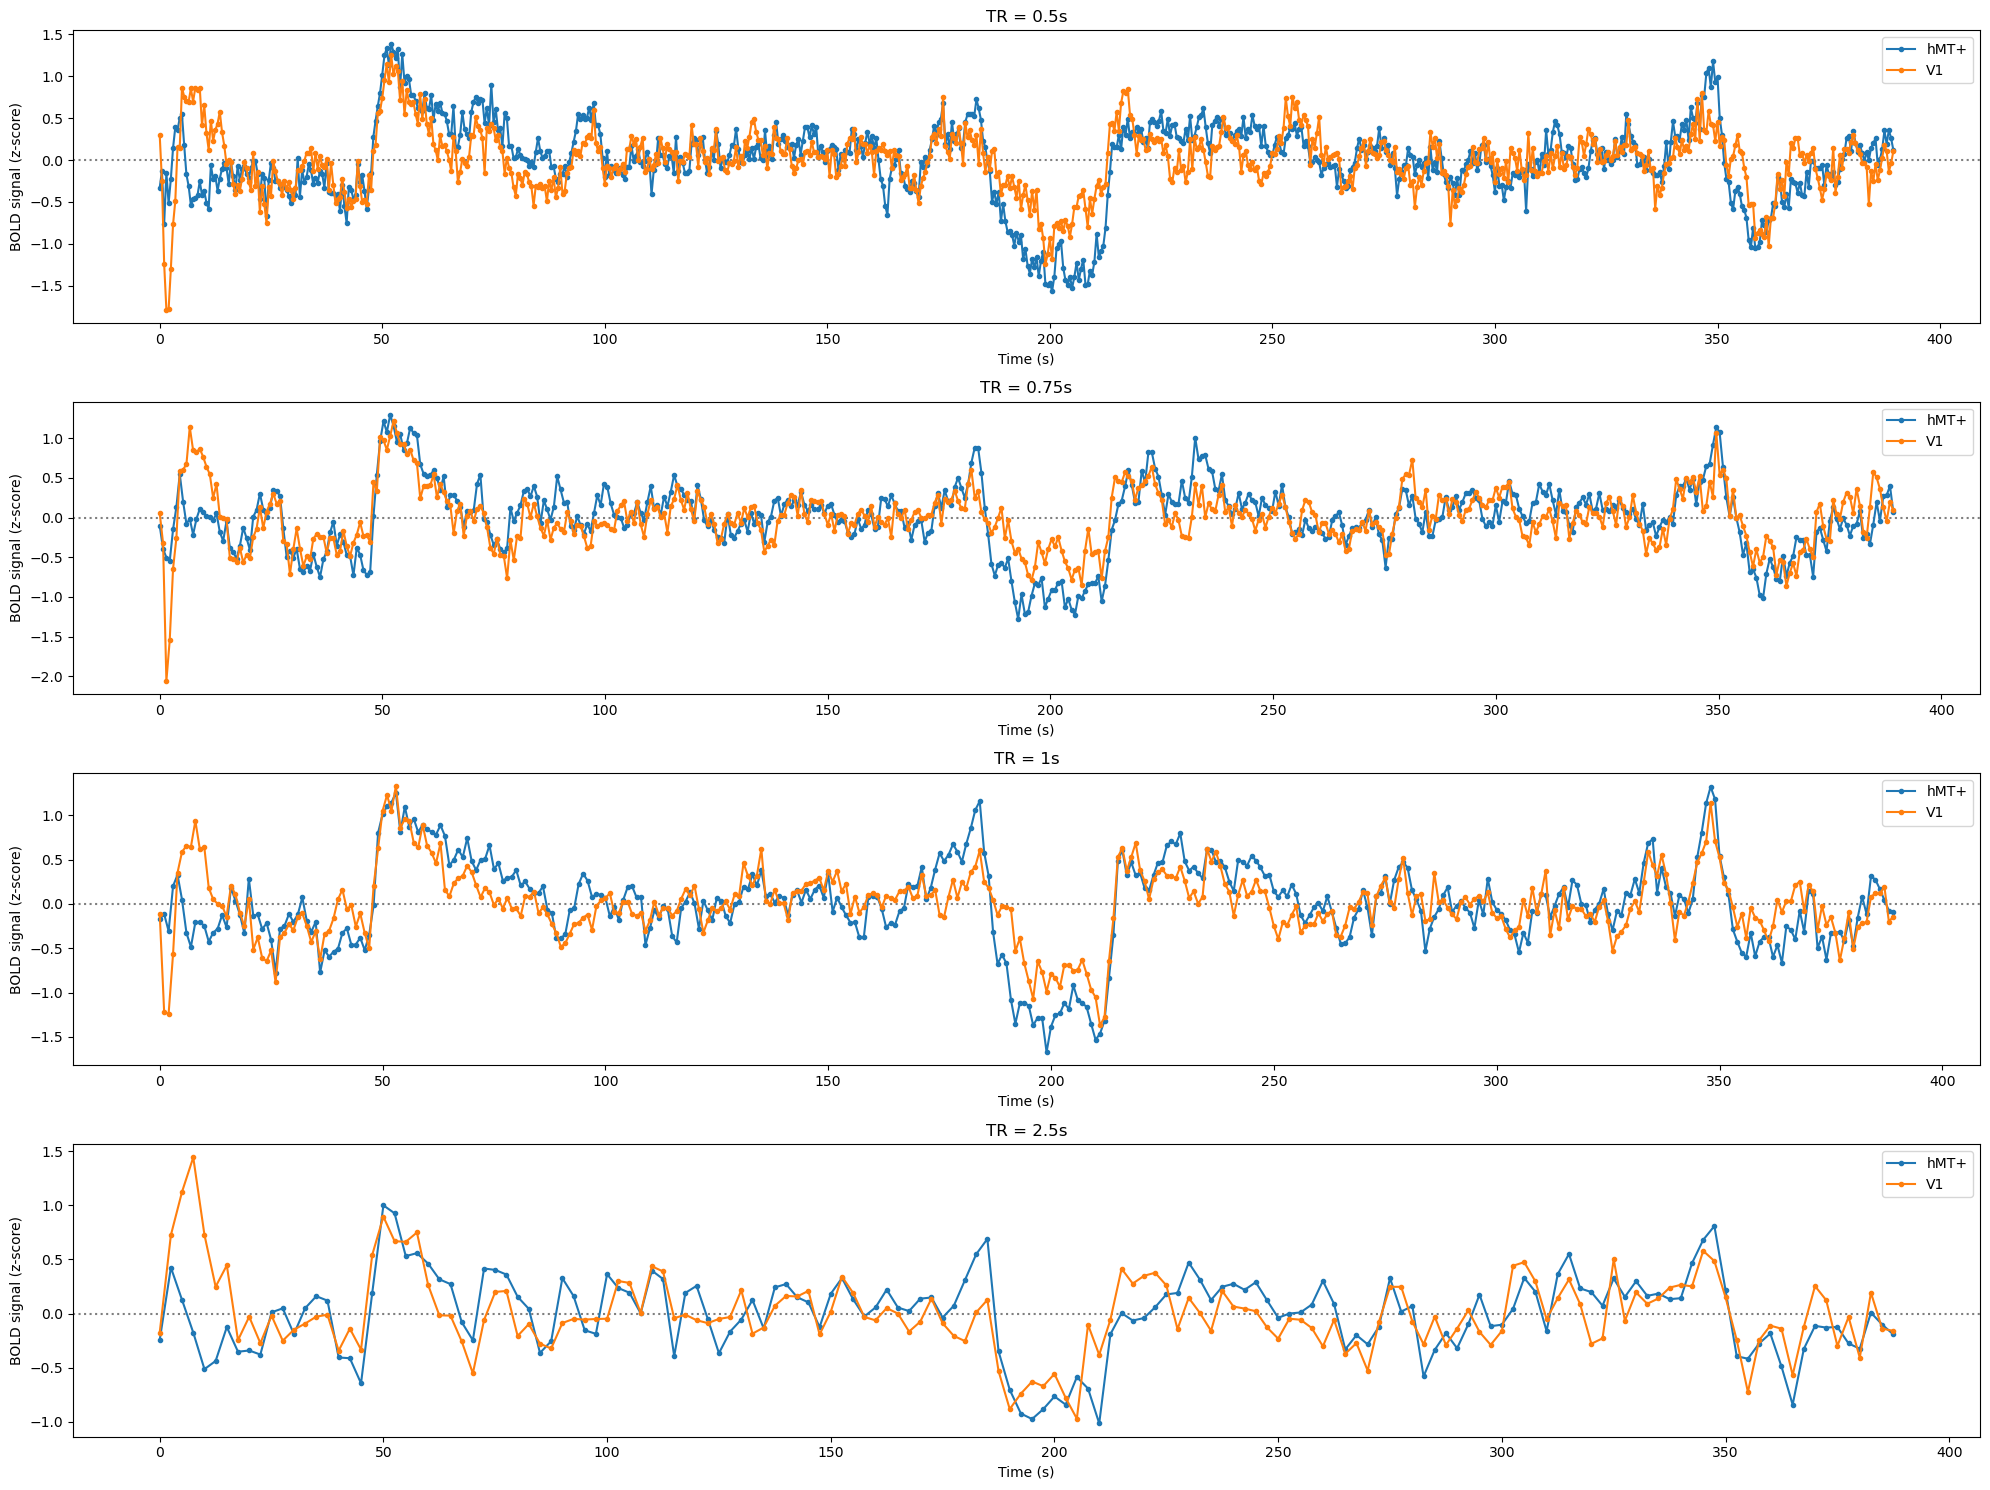

In [50]:
# Plot timecourses per TR
f, axs = plt.subplots(len(tr_list), 1, figsize=(20, 15))

for tr_idx, tr in enumerate(tr_list):

    n_volumes = n_volumes_list[tr_idx]

    m1 = df[df['tr']==tr]['bilateral_mt'].mean()
    s1 = df[df['tr']==tr]['bilateral_mt'].values.std()
    m2 = df[df['tr']==tr]['bilateral_v1'].mean()
    s2 = df[df['tr']==tr]['bilateral_v1'].values.std()

    # create time vector based on the number of time points and the tr
    time_vector = np.arange(0, n_volumes*tr, tr)

    # add horizontal line at y=0
    axs[tr_idx].axhline(y=0, color='k', linestyle=':', alpha=0.5)

    # plot m1 and m2 in different colors with legend
    axs[tr_idx].plot(time_vector, m1, label='hMT+', marker='.')
    axs[tr_idx].plot(time_vector, m2, label='V1', marker='.')
    axs[tr_idx].legend()

    # plot the standard deviation as a shaded area
    #axs[tr_idx].fill_between(time_vector, m1-s1, m1+s1, alpha=0.2)
    #axs[tr_idx].fill_between(time_vector, m2-s2, m2+s2, alpha=0.2)

    # add title and axis labels
    axs[tr_idx].set_title('TR = ' + str(tr) + 's')
    axs[tr_idx].set_xlabel('Time (s)')
    axs[tr_idx].set_ylabel('BOLD signal (z-score)')

plt.tight_layout()
plt.show()

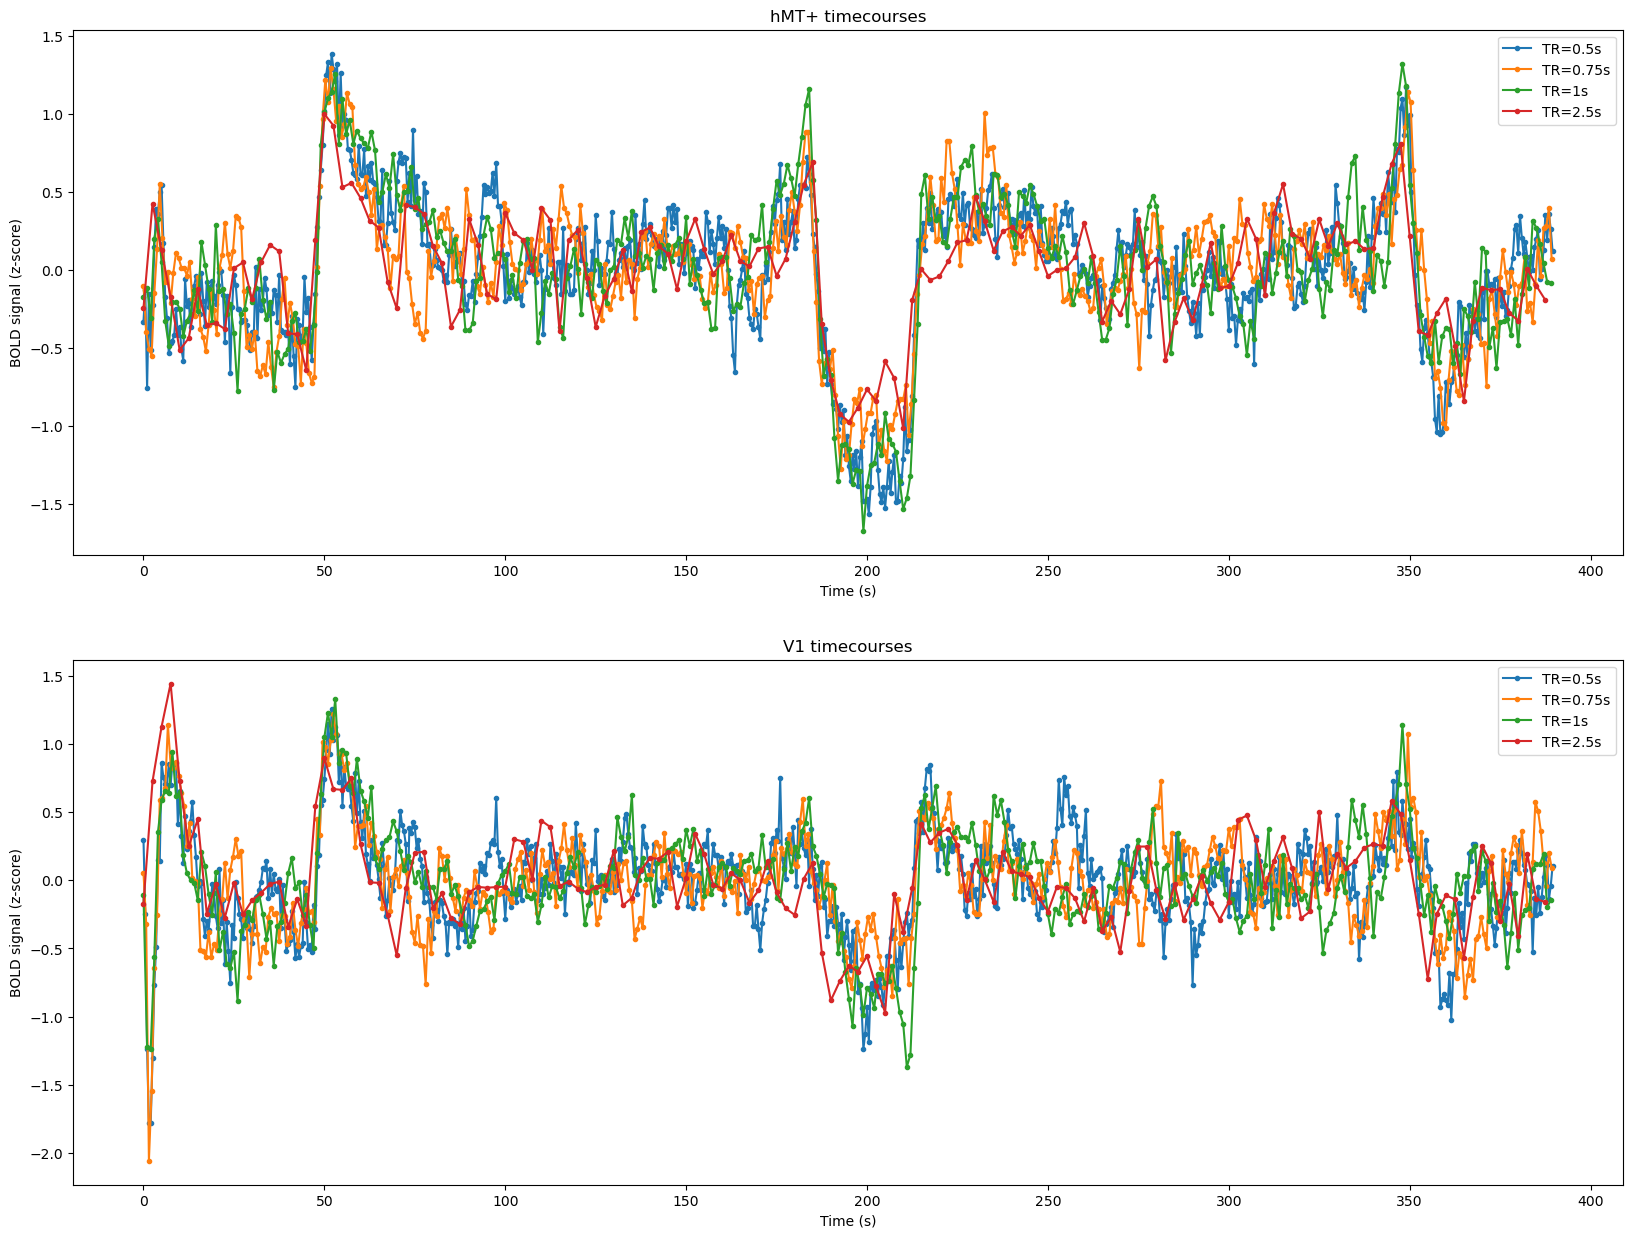

In [51]:
# Plot timecourses per ROI (bilateral_mt and bilateral_v1)
f, axs = plt.subplots(2, 1, figsize=(20, 15))

time_vectors = {}

# create time vectors for each TR
for tr_idx,tr in enumerate(tr_list):
    n_volumes = n_volumes_list[tr_idx]
    time_vectors[tr_idx] = np.arange(0, n_volumes*tr, tr)

# plot hMT+ timecourses for all TRs
for tr_idx,tr in enumerate(tr_list):
    m1 = df[df['tr']==tr]['bilateral_mt'].mean()
    s1 = df[df['tr']==tr]['bilateral_mt'].values.std()

    axs[0].plot(time_vectors[tr_idx], m1, label='TR='+str(tr)+'s', marker='.')
    #axs[0].fill_between(time_vectors[tr_idx], m1-s1, m1+s1, alpha=0.2)

axs[0].set_title('hMT+ timecourses')
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('BOLD signal (z-score)')
axs[0].legend()

# plot V1 timecourses for all TRs
for tr_idx,tr in enumerate(tr_list):
    m1 = df[df['tr']==tr]['bilateral_v1'].mean()
    s1 = df[df['tr']==tr]['bilateral_v1'].values.std()

    axs[1].plot(time_vectors[tr_idx], m1, label='TR='+str(tr)+'s', marker='.')
    #axs[1].fill_between(time_vectors[tr_idx], m1-s1, m1+s1, alpha=0.2)

axs[1].set_title('V1 timecourses')
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('BOLD signal (z-score)')
axs[1].legend()

plt.show()

# ERAs

In [52]:
import src.feedbackFunctions as ff

# Load sample events file per TR for sub-01
run_type = 'UA'
active_cond_name = 'motion'

static_events_indexes_arr = np.zeros((len(tr_list), 500))
active_events_indexes_arr = np.zeros((len(tr_list), 500))

for tr_idx,tr in enumerate(tr_list):

    task_label = f'task-{run_type}_acq-{round(tr*1000):04}_run-1'
    events_file = os.path.join(data_dir, 'sub-01', 'func', f'sub-01_{task_label}_events.tsv')

    static_events_indexes, active_events_indexes = ff.read_events(events_file,hrf_delay,tr,active_cond_name)

    # save to array
    static_events_indexes_arr[tr_idx,:len(static_events_indexes)] = static_events_indexes
    active_events_indexes_arr[tr_idx,:len(active_events_indexes)] = active_events_indexes

verticalMarkers = np.array([15.5,45.5,164.5,179.5,209.5,329.5,344.5,374.5]) + hrf_delay # these mark the change of condition (including hrf_delay)

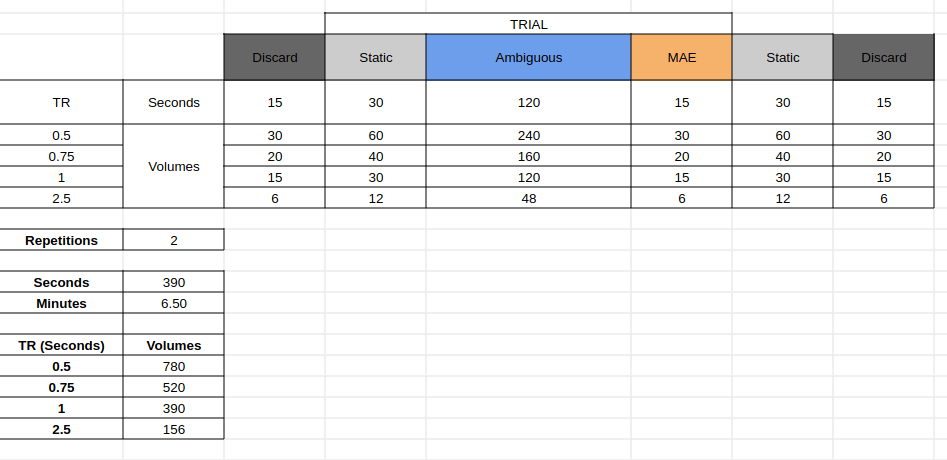

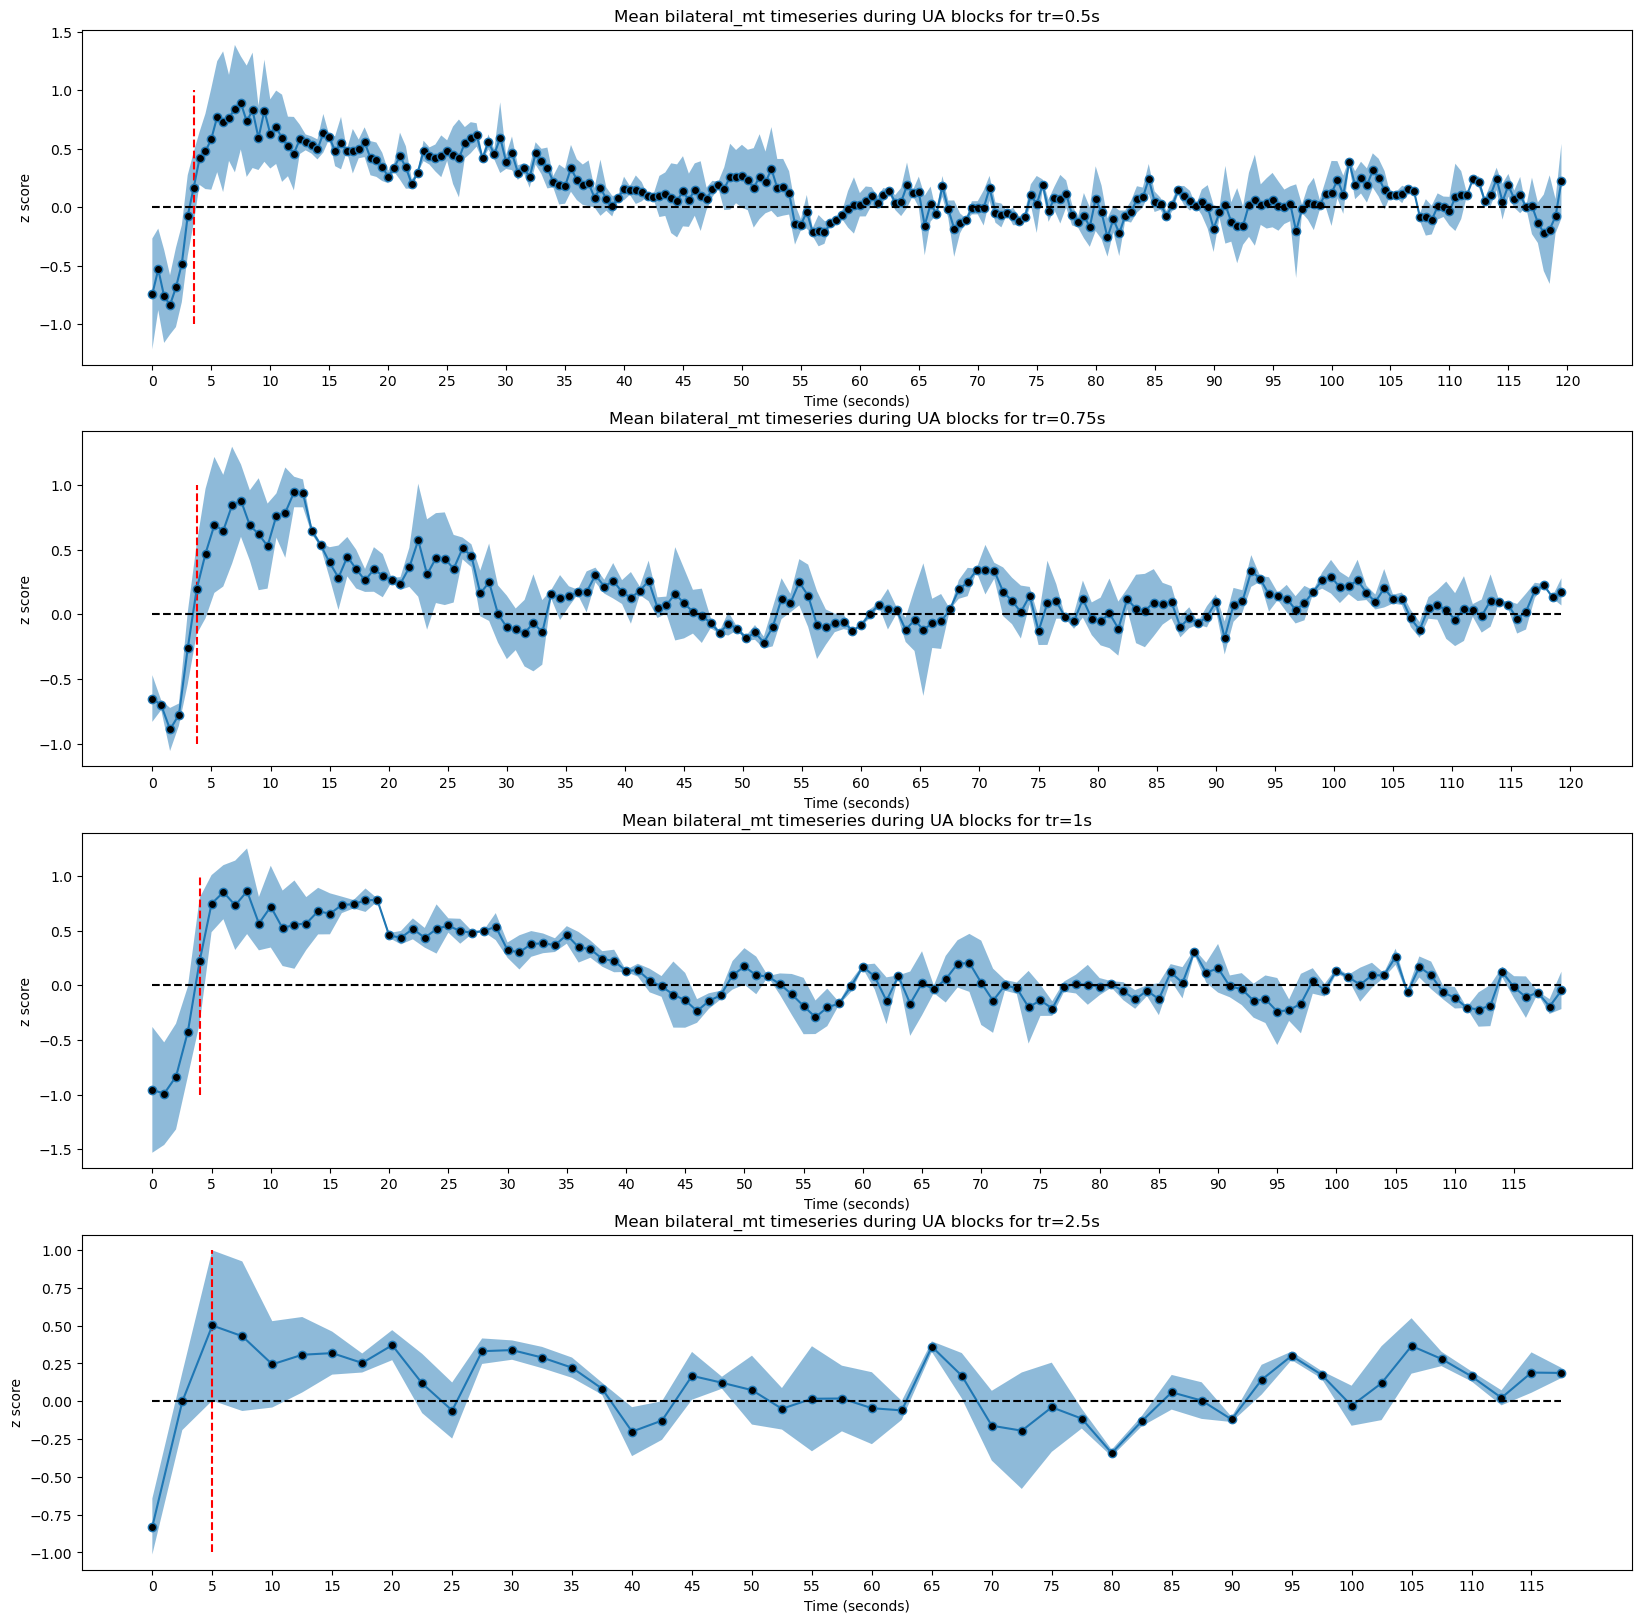

In [62]:
# plot ERA with mean PSC to static timeseries for each tr
f_psc, axs_psc = plt.subplots(4, 1, figsize=(20, 20))
roi_name = 'bilateral_mt'

for tr_idx,tr in enumerate(tr_list):

    # extract static_events_indexes for each tr excluding zeros (a big array was initialized)
    static_events_indexes_aux = static_events_indexes_arr[tr_idx, static_events_indexes_arr[tr_idx,:] != 0]
    active_events_indexes_aux = active_events_indexes_arr[tr_idx, active_events_indexes_arr[tr_idx,:] != 0]

    time_series = df[df['tr']==tr][roi_name]
    time_series = np.array(time_series.tolist()) # convert time_series to numpy array
    time_series_static = time_series[:,static_events_indexes_aux.astype(int)]

    # calculate mean of each row
    m = time_series_static.mean(axis=1)

    # substrat m from time_series and divide by abs(m)
    time_series_psc = time_series#(time_series - m[:,None]) #/ abs(m[:,None])

    time_series_mean = time_series_psc.mean(axis=0)
    time_series_std = time_series_psc.std(axis=0)

    # estimate event related response
    time_series_mean_active = time_series_mean[active_events_indexes_aux.astype(int)]
    time_series_mean_active_length = time_series_mean_active.shape[0]//2

    # reshape time_series_mean_active to two columns with half the points each
    time_series_mean_active = time_series_mean_active.reshape((2,time_series_mean_active_length)).T

    # estimate mean and std
    time_series_mean_psc_active_mean = time_series_mean_active.mean(axis=1)
    time_series_mean_psc_active_std = time_series_mean_active.std(axis=1)

    # create time vector based on the number of time points and the tr
    time_vector = np.arange(0, time_series_mean_active_length*tr, tr)

    data_to_plot_mean = time_series_mean_psc_active_mean
    data_to_plot_std = time_series_mean_psc_active_std

    # add lines in the first point above y=0
    axs_psc[tr_idx].vlines(time_vector[data_to_plot_mean > 0][0], -1, 1, color='r', linestyles='dashed')

    # plot mean and std timeseries
    axs_psc[tr_idx].plot(time_vector, data_to_plot_mean, marker = 'o', markerfacecolor = 'black')
    axs_psc[tr_idx].fill_between(time_vector, data_to_plot_mean-data_to_plot_std, data_to_plot_mean+data_to_plot_std, alpha=0.5)
    axs_psc[tr_idx].hlines(0, 0, time_vector[-1], colors='k', linestyles='dashed')

    axs_psc[tr_idx].set_title(f'Mean {roi_name} timeseries during UA blocks for tr='+str(tr)+'s')
    axs_psc[tr_idx].set_xlabel('Time (seconds)')
    axs_psc[tr_idx].set_ylabel('z score')
    axs_psc[tr_idx].set_xticks(np.arange(0,time_vector[-1]+1,5))